In [1]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt


def draw_landmarks_on_image(rgb_image, detection_result):
  face_landmarks_list = detection_result.face_landmarks
  annotated_image = np.copy(rgb_image)

  # Loop through the detected faces to visualize - i.e. process each person 1 by 1
  for idx in range(len(face_landmarks_list)):
    face_landmarks = face_landmarks_list[idx]

    # Draw the face landmarks.


    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION, # Tesselation layer -> creates 3D mesh over skin
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style())
    
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS, # Contours layer -> draw distinct outline paths around major features 
        landmark_drawing_spec=None,
        connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS, # Left Iris Layer -> connects dots in tiny circle around left iris 
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=face_landmarks,
        connections=vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS, # Right Iris Layer -> connects dots in tiny circle around right iris 
          landmark_drawing_spec=None,
          connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style())

  return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
  # Extract the face blendshapes category names and scores.
  face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
  face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
  # The blendshapes are ordered in decreasing score value.
  face_blendshapes_ranks = range(len(face_blendshapes_names))

  fig, ax = plt.subplots(figsize=(12, 12))
  bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
  ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
  ax.invert_yaxis()

  # Label each bar with values
  for score, patch in zip(face_blendshapes_scores, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

  ax.set_xlabel('Score')
  ax.set_title("Face Blendshapes")
  plt.tight_layout()
  plt.show()

In [2]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an FaceLandmarker object.
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=5)
detector = vision.FaceLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("obama-fam.jpeg")

# STEP 4: Detect face landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
cv2.imshow("Facial Landmarks", cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))

cv2.waitKey(0)           # Tells the OS to freeze the window open until you press ANY key
cv2.destroyAllWindows()  # Safely closes the GUI memory threads when a key is pressed

W0000 00:00:1779251850.475512  498290 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779251850.667171  498290 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779251850.675420  498308 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-U)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779251850.689704  498293 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779251850.737636  498301 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


RuntimeError: Failed to load image from file

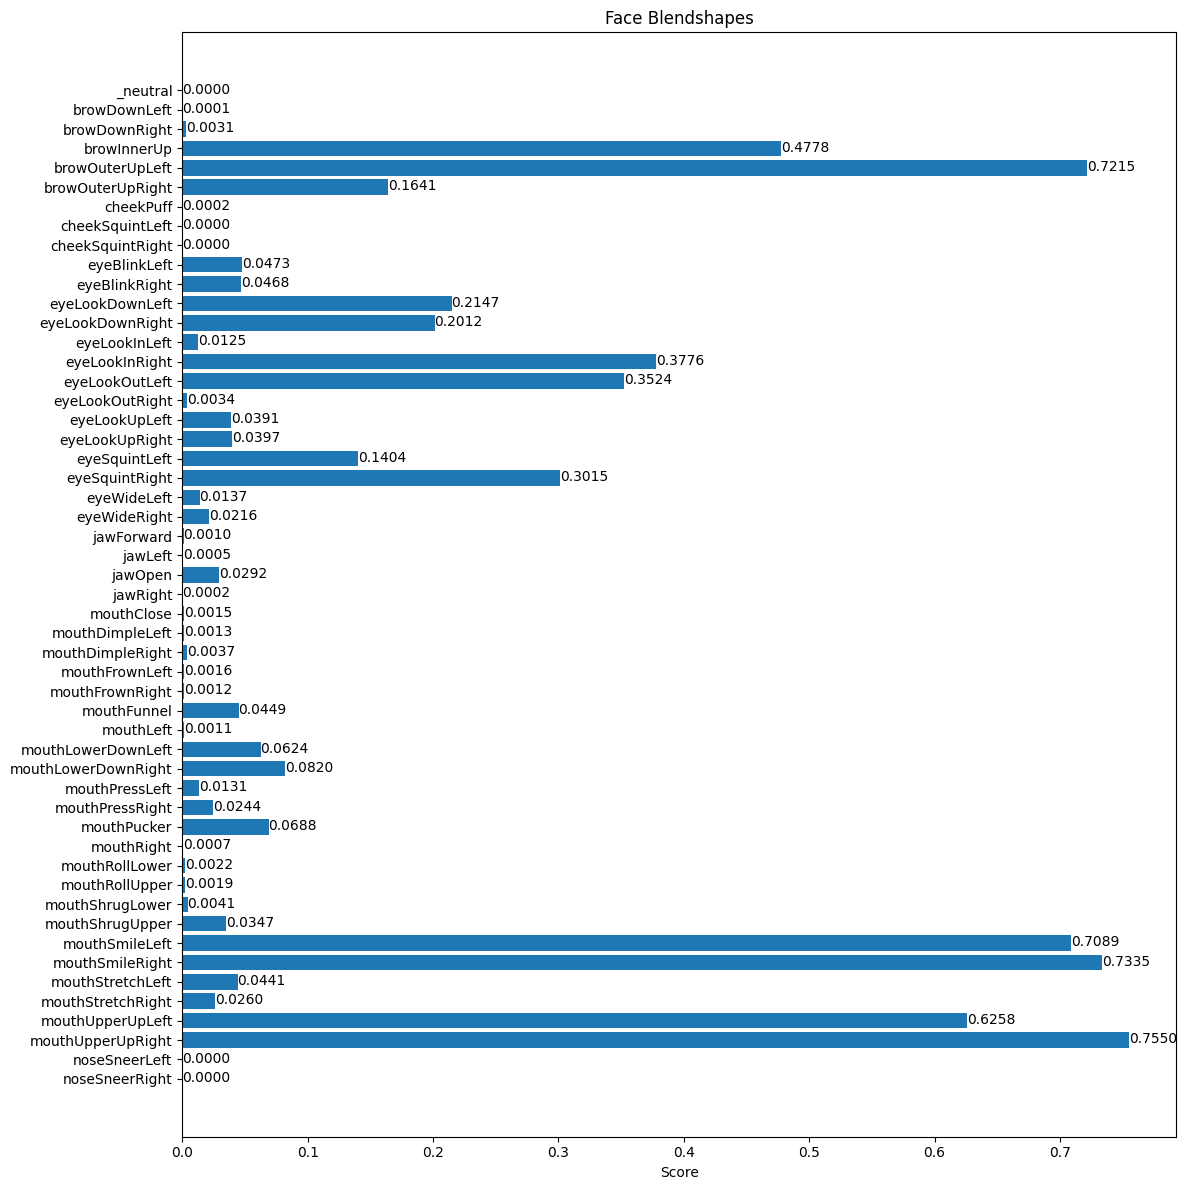

In [ ]:
# Bar graph of facial expression features - the score represents the ratio of the expression to its theoretical maximum
plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])

In [ ]:
# test: seeing multiple faces
print(len(detection_result.face_landmarks))

4


In [6]:
from pathlib import Path 
import os 

def draw_circle(img, x_pos, y_pos):
    print(type(img))
    cv2.circle(
        img=img,
        center=(x_pos, y_pos),
        radius=5,
        color=(0, 255, 0),
        thickness=1
    )
    return None


def process_faces(folder_name: str, total_faces: int):
    """
    faces_folder: list containing all files
    total_faces: contains the total # of faces across all files
    """
    
    # build an output folder - ignore if already exists 
    os.makedirs("output_faces", exist_ok=True) 

    # collect image paths
    faces_folder = list(Path(folder_name).glob("*"))

    cols = 3 if total_faces > 2 else 1
    rows = int(np.ceil(total_faces / cols))

    _, axes = plt.subplots(
        rows,
        cols,
        figsize=(2 * cols, 2 * rows)
    )

    # make axes always iterable
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    axes = np.array(axes).flatten()

    plot_idx = 0

    # iterate through each image in the folder 
    for idx in range(len(faces_folder)):

        print(f"index: {idx}\n")
        img = cv2.imread(faces_folder[idx])
        img_w, img_h = img.shape[1], img.shape[0]

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        )

        detection_result = detector.detect(mp_image)

        if len(detection_result.face_landmarks) == 0: 
            print(f"[ERROR] Could not find a face in {faces_folder[idx]}")
            continue

        face_count = len(detection_result.face_landmarks)
        print(f"{faces_folder[idx]}: {face_count}")

        # iterate through each face in each image 
        for face in detection_result.face_landmarks:
            
            # Extract known features
            left_eye_center = face[468]
            right_eye_center = face[473]
            nose_tip = face[4]

            # De-normalize coordinates to allow indexing original image 
            left_eye_x = int(left_eye_center.x * img_w)
            left_eye_y = int(left_eye_center.y * img_h)

            right_eye_x = int(right_eye_center.x * img_w)
            right_eye_y = int(right_eye_center.y * img_h)

            nose_tip_x = int(nose_tip.x * img_w)
            nose_tip_y = int(nose_tip.y * img_h)

            # Feature coordinates in original image 
            left_eye = (left_eye_x , left_eye_y)
            right_eye = (right_eye_x, right_eye_y)
            nose = (nose_tip_x, nose_tip_y)

            # Target coordinates for feature transform (from specifications doc)
            new_left_eye = (40, 40)
            new_right_eye = (85, 40)
            new_nose = (63, 70)

            # Source array
            src = np.array([
                left_eye,
                right_eye,
                nose
            ], dtype=np.float32)

            # Destination array
            dst = np.array([
                new_left_eye, 
                new_right_eye,
                new_nose
            ], dtype=np.float32)
            
            # Estimate coordinate tranformation required to take source points to destination   
            M, _ = cv2.estimateAffinePartial2D(src, dst)

            # Compute affine transformation on original image - focused around a 125x125 window
            aligned_img = cv2.warpAffine(img, M, (125, 125))

            # Convert image to rgb (for display)
            img_rgb = cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB)

            # Display each face individually 
            axes[plot_idx].imshow(img_rgb)
            axes[plot_idx].axis("off")

            plot_idx += 1 # increment 'face count'




index: 0

faces/jeff2.jpeg: 1
index: 1

faces/taz.jpg: 1
index: 2

faces/jeff1.jpeg: 1
index: 3

faces/pope.jpeg: 1
index: 4

faces/obama-fam.jpeg: 4
index: 5

faces/trump-face.jpeg: 1
index: 6

faces/jeffDahm.jpeg: 2
index: 7

faces/obamav3.jpg: 1
index: 8

[ERROR] Could not find a face in faces/obama-face.jpeg


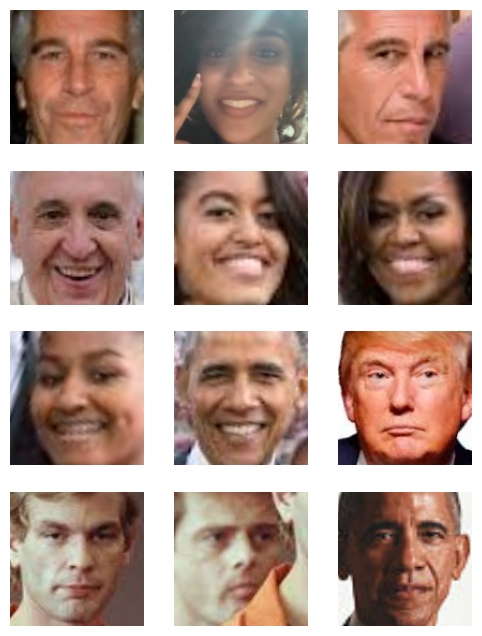

In [7]:
process_faces("faces", 11)